<a href="https://colab.research.google.com/github/kutay25/music-classification/blob/main/cs464_image_transfer_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing dataset

In [1]:
!git clone https://github.com/mdeff/fma.git

Cloning into 'fma'...
remote: Enumerating objects: 823, done.
remote: Counting objects: 100% (822/822), done.
remote: Compressing objects: 100% (287/287), done.
remote: Total 823 (delta 532), reused 621 (delta 527), pack-reused 1 (from 1)
Receiving objects: 100% (823/823), 4.08 MiB | 20.77 MiB/s, done.
Resolving deltas: 100% (532/532), done.


In [2]:
!cd fma

!curl -O https://os.unil.cloud.switch.ch/fma/fma_metadata.zip
!curl -O https://os.unil.cloud.switch.ch/fma/fma_small.zip

!echo "f0df49ffe5f2a6008d7dc83c6915b31835dfe733  fma_metadata.zip" | sha1sum -c -
!echo "ade154f733639d52e35e32f5593efe5be76c6d70  fma_small.zip"    | sha1sum -c -

!unzip fma_metadata.zip
!unzip fma_small.zip

!cd ..

Görüntülenen çıkış son 5000 satıra kısaltıldı.
 bunzipping: fma_small/068/068601.mp3  
 bunzipping: fma_small/068/068680.mp3  
 bunzipping: fma_small/068/068682.mp3  
 bunzipping: fma_small/068/068683.mp3  
 bunzipping: fma_small/068/068820.mp3  
 bunzipping: fma_small/068/068821.mp3  
 bunzipping: fma_small/068/068837.mp3  
 bunzipping: fma_small/068/068838.mp3  
 bunzipping: fma_small/068/068839.mp3  
 bunzipping: fma_small/068/068840.mp3  
 bunzipping: fma_small/068/068841.mp3  
 bunzipping: fma_small/068/068842.mp3  
 bunzipping: fma_small/068/068843.mp3  
 bunzipping: fma_small/068/068844.mp3  
 bunzipping: fma_small/068/068851.mp3  
 bunzipping: fma_small/068/068852.mp3  
 bunzipping: fma_small/068/068853.mp3  
 bunzipping: fma_small/068/068854.mp3  
 bunzipping: fma_small/068/068860.mp3  
 bunzipping: fma_small/068/068861.mp3  
 bunzipping: fma_small/068/068862.mp3  
 bunzipping: fma_small/068/068869.mp3  
 bunzipping: fma_small/068/068872.mp3  
 bunzipping: fma_small/068/068875

In [3]:
!pwd
print("---")
!ls .
print("---")
!ls ./fma
print("---")
!ls ./fma_metadata
print("---")
!ls ./fma_small
print("---")
!ls ./fma_small/000

/content
---
fma  fma_metadata  fma_metadata.zip  fma_small	fma_small.zip  sample_data
---
analysis.ipynb	 creation.py  figures	   README.md	     usage.ipynb
baselines.ipynb  data	      LICENSE.txt  requirements.txt  utils.py
creation.ipynb	 features.py  makefile	   setup.py	     webapi.ipynb
---
checksums     features.csv  not_found.pickle  raw_artists.csv	raw_genres.csv	README.txt
echonest.csv  genres.csv    raw_albums.csv    raw_echonest.csv	raw_tracks.csv	tracks.csv
---
000  009  018  027  036  045  054  063	072  081  090  099  108  117  126  135	144  153
001  010  019  028  037  046  055  064	073  082  091  100  109  118  127  136	145  154
002  011  020  029  038  047  056  065	074  083  092  101  110  119  128  137	146  155
003  012  021  030  039  048  057  066	075  084  093  102  111  120  129  138	147  checksums
004  013  022  031  040  049  058  067	076  085  094  103  112  121  130  139	148  README.txt
005  014  023  032  041  050  059  068	077  086  095  104  113  122  131 

## Formatting the dataset

In [6]:
import glob, os, pandas as pd, numpy as np, tensorflow as tf, librosa
from sklearn.model_selection import train_test_split

# --- Setting mixed precision ---------------------------------------------
policy = tf.keras.mixed_precision.Policy('mixed_float16')
tf.keras.mixed_precision.set_global_policy(policy)

# --- load full metadata table (2‑row header) -----------------------------
tracks = pd.read_csv("./fma_metadata/tracks.csv",
                     index_col=0, header=[0, 1])

# --- collect the track_ids that exist in fma_small -----------------------
audio_paths = glob.glob("./fma_small/*/*.mp3")
track_ids   = [int(os.path.splitext(os.path.basename(p))[0]) for p in audio_paths]

df = tracks.loc[track_ids]
df = df[df[('track', 'genre_top')].notna()]

df["path"] = ["./fma_small/{:03d}/{:06d}.mp3".format(t//1000, t) for t in df.index]

# mapping ints to class names
label_names = sorted(df[('track', 'genre_top')].unique())
label2idx   = {name: idx for idx, name in enumerate(label_names)}
df["label"] = df[('track', 'genre_top')].map(label2idx)

print("Found", len(df), "tracks with genre_top and audio")
print("Classes:", label_names)


Found 8000 tracks with genre_top and audio
Classes: ['Electronic', 'Experimental', 'Folk', 'Hip-Hop', 'Instrumental', 'International', 'Pop', 'Rock']


In [7]:
train_df, test_df = train_test_split(df, test_size=0.10,
                                     stratify=df["label"], random_state=42)
train_df, val_df  = train_test_split(train_df, test_size=0.1111,
                                     stratify=train_df["label"], random_state=42)

print(len(train_df), len(val_df), len(test_df))
num_classes = len(label_names)


6400 800 800


## Setting up the experiment

Parameters:

In [ ]:
SR          = 44_100
SEG_LEN     = 10
N_MELS      = 128
N_FFT       = 2048
HOP         = 512
IMG_SIZE    = 224
BATCH       = 128

Setting up functions:

In [15]:
def slice_center(y, length):
    if len(y) < length:
        pad = length - len(y)
        y = np.pad(y, (pad//2, pad - pad//2))
    start = (len(y) - length) // 2
    return y[start:start + length]

def audio_to_img(y):
    S = librosa.feature.melspectrogram(y=y, sr=SR, n_fft=N_FFT,
                                       hop_length=HOP, n_mels=N_MELS)
    S = librosa.power_to_db(S, ref=np.max)
    S = (S - S.min()) / (S.max() - S.min() + 1e-6)
    S = tf.image.resize(S[..., None], (IMG_SIZE, IMG_SIZE)).numpy()
    S = np.repeat(S, 3, axis=-1).astype(np.float32)
    return S

def load_and_process(path, label, train_mode=True):
    p = path.numpy().decode("utf‑8")
    try:
        y, _ = librosa.load(p, sr=SR, mono=True)
    except Exception as e:
        # Log the error and use silence as a fallback
        print(f"Error loading {p}: {e}")
        y = np.zeros(SEG_LEN * SR, dtype=np.float32)
    if train_mode:
        max_off = max(0, len(y) - SEG_LEN * SR)
        off = np.random.randint(0, max_off + 1) if max_off else 0
        y = y[off: off + SEG_LEN * SR]
    else:
        y = slice_center(y, SEG_LEN * SR)
    img = audio_to_img(y)
    return img, label

def tf_wrapper(train_mode):
    def _fn(path, label):
        img, lbl = tf.py_function(func=load_and_process,
                                  inp=[path, label, train_mode],
                                  Tout=[tf.float32, tf.int64])
        img.set_shape((IMG_SIZE, IMG_SIZE, 3))
        lbl.set_shape(())
        return img, lbl
    return _fn

def make_ds(df, train_mode):
    paths  = df["path"].values
    labels = df["label"].values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if train_mode:
        ds = ds.shuffle(buffer_size=5000, reshuffle_each_iteration=True)
    ds = (ds.map(tf_wrapper(train_mode), num_parallel_calls=tf.data.AUTOTUNE)
            .cache()
            .batch(BATCH)
            .prefetch(buffer_size=tf.data.AUTOTUNE))
    return ds

Splitting the dataset into train / validation / test

In [ ]:
train_ds = make_ds(train_df, True)
val_ds   = make_ds(val_df,   False)
test_ds  = make_ds(test_df,  False)

## The Model

In [32]:
base = tf.keras.applications.ResNet50(weights="imagenet",
                                      include_top=False,
                                      input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze all layers except the last ~30 layers (last convolutional block)
fine_tune_at = len(base.layers) - 30
for layer in base.layers[:fine_tune_at]:
    layer.trainable = False
for layer in base.layers[fine_tune_at:]:
    layer.trainable = True

# Print summary of trainable layers
trainable_count = sum(1 for layer in base.layers if layer.trainable)
print(f"Training the last {trainable_count} out of {len(base.layers)} total layers in ResNet50")

model = tf.keras.Sequential([
    base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Training the last 30 out of 175 total layers in ResNet50


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_6           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 8)                   │           2,056 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,114,312 (91.99 MB)

 Trainable params: 14,976,776 (57.13 MB)

 Non-trainable params: 9,137,536 (34.86 MB)

## Training

In [33]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 190ms/step - accuracy: 0.2430 - loss: 1.9747 - val_accuracy: 0.1250 - val_loss: 2.1491
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.3990 - loss: 1.6591 - val_accuracy: 0.1275 - val_loss: 2.1968
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4333 - loss: 1.5642 - val_accuracy: 0.1538 - val_loss: 2.2812
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4646 - loss: 1.4939 - val_accuracy: 0.1663 - val_loss: 2.2033
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.4837 - loss: 1.4443 - val_accuracy: 0.1425 - val_loss: 2.1347
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5076 - loss: 1.3982 - val_accuracy: 0.2175 - val_loss: 1.9220
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5313 - loss: 1.3504 - val_accuracy: 0.3663 - val_loss: 1.7248
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5363 - loss: 1.3230 - val_accuracy: 0.4263 -

#### Reporting the results

In [34]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nModel test accuracy: {test_acc:.3%}")

# Generate detailed classification report
print("\n--- Classification Report ---")
y_true, y_pred = [], []
for x, y in test_ds:
    y_true.extend(y.numpy())
    y_pred.extend(np.argmax(model.predict(x, verbose=0), axis=1))

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred, target_names=label_names))


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4592 - loss: 1.5104

Model test accuracy: 46.000%

--- Classification Report ---
               precision    recall  f1-score   support

   Electronic       0.41      0.37      0.39       100
 Experimental       0.51      0.35      0.42       100
         Folk       0.40      0.78      0.53       100
      Hip-Hop       0.42      0.77      0.54       100
 Instrumental       0.57      0.42      0.48       100
International       0.56      0.48      0.52       100
          Pop       0.27      0.15      0.19       100
         Rock       0.74      0.35      0.48       100

     accuracy                           0.46       800
    macro avg       0.49      0.46      0.44       800
 weighted avg       0.49      0.46      0.44       800



#### Saving the weights to Google Drive

In [35]:
from google.colab import drive
drive.mount("/content/drive")

save_path = "/content/drive/MyDrive/fma_resnet50_single_stage.h5"
model.save(save_path)
print(f"Model saved to {save_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model saved to /content/drive/MyDrive/fma_resnet50_single_stage.h5


## Displaying results

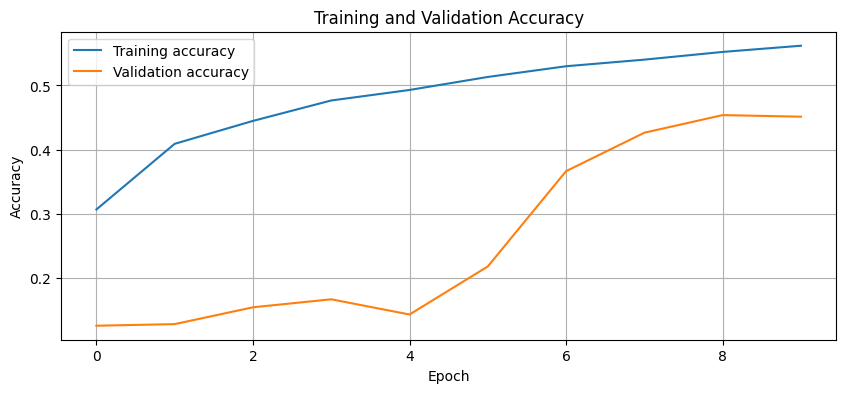

In [36]:
import matplotlib.pyplot as plt

def plot_history(history, metric='accuracy'):
    plt.figure(figsize=(10, 4))
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
    plt.xlabel('Epoch')
    plt.ylabel(metric.capitalize())
    plt.title(f'Training and Validation {metric.capitalize()}')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history)